# Submissao 3 - Ensemble de Modelos para Deteccao de Autoria

Notebook criado para o projeto **AP-25_26** com foco em melhorar a performance combinando os melhores modelos das submissões anteriores (Subm1/Subm2) com um novo modelo PyTorch.

## Objetivo
- Treino e validacao com `../data/dataset_limpo.csv`
- Teste com `../data/dataset-exemplos.csv`
- Ensemble com votação ponderada:
  - **PyTorch MLP** (novo, 68.8% accuracy)
  - **Subm2-A PyTorch+sklearn** (74% accuracy)
  - **Subm2-B DistilBERT** (68% accuracy)
- Inferencia para submissao com `../subm3.csv`

In [60]:
import copy
import random
import warnings
from pathlib import Path

import joblib
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.model_selection import train_test_split
from sklearn.pipeline import FeatureUnion

from transformers import DistilBertTokenizerFast, DistilBertForSequenceClassification
from transformers.utils import logging as hf_logging

warnings.filterwarnings('ignore')
hf_logging.set_verbosity_error()

SEED = 42
RUN_MODE = 'train'  # 'train' ou 'load'
BERT_MAX_EPOCHS = 4
BERT_BATCH_SIZE = 16

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('DEVICE:', DEVICE)
print('RUN_MODE:', RUN_MODE)
print('BERT_MAX_EPOCHS:', BERT_MAX_EPOCHS)
print('BERT_BATCH_SIZE:', BERT_BATCH_SIZE)

DEVICE: cpu
RUN_MODE: train
BERT_MAX_EPOCHS: 4
BERT_BATCH_SIZE: 16


In [61]:
BASE_DIR = Path('..').resolve()

TRAIN_PATH = BASE_DIR / 'data' / 'dataset_limpo.csv'
TEST_PATH = BASE_DIR / 'data' / 'dataset-exemplos.csv'
SUBM3_PATH = BASE_DIR / 'subm3.csv'
REVEALED_1 = BASE_DIR / 'data' / 'subm1_labels_revealed.csv'
REVEALED_2 = BASE_DIR / 'data' / 'subm2_labels_revealed.csv'

SUBM1_DIR = BASE_DIR / 'Subm1'
SUBM2_DIR = BASE_DIR / 'Subm2'
SUBM3_DIR = BASE_DIR / 'Subm3'
MODEL_DIR = BASE_DIR / 'models' / 'pytorch_models'
SAVED_DIR = BASE_DIR / 'saved'
SUBM3_DIR.mkdir(parents=True, exist_ok=True)
MODEL_DIR.mkdir(parents=True, exist_ok=True)
SAVED_DIR.mkdir(parents=True, exist_ok=True)

MLP_MODEL_PATH = SAVED_DIR / 'mlp_subm3_final.pt'
MLP_VECTORIZER_PATH = SAVED_DIR / 'mlp_subm3_vectorizer.joblib'
MLP_META_PATH = SAVED_DIR / 'mlp_subm3_meta.joblib'
DNN_MODEL_PATH = SAVED_DIR / 'dnn_subm2a_final.pt'
DNN_VECTORIZER_PATH = SAVED_DIR / 'dnn_subm2a_vectorizer.joblib'
DNN_META_PATH = SAVED_DIR / 'dnn_subm2a_meta.joblib'
BERT_DIR = SAVED_DIR / 'distilbert_subm2b_final'
BERT_META_PATH = SAVED_DIR / 'distilbert_subm2b_meta.joblib'
ENSEMBLE_PATH = SAVED_DIR / 'subm3_ensemble_config.joblib'

print('BASE_DIR:', BASE_DIR)
print('TRAIN_PATH existe?', TRAIN_PATH.exists())
print('TEST_PATH existe?', TEST_PATH.exists())
print('SUBM3_PATH existe?', SUBM3_PATH.exists())
print('SAVED_DIR:', SAVED_DIR)

BASE_DIR: /Users/nunoaraujo/MIA/AP/AP-25_26
TRAIN_PATH existe? True
TEST_PATH existe? True
SUBM3_PATH existe? True
SAVED_DIR: /Users/nunoaraujo/MIA/AP/AP-25_26/saved


In [55]:
def read_semicolon_csv(path: Path) -> pd.DataFrame:
    # Tenta ler ficheiros com potencial BOM no cabecalho.
    return pd.read_csv(path, sep=';', encoding='utf-8-sig')


def normalize_text_series(s: pd.Series) -> pd.Series:
    return (
        s.fillna('')
         .astype(str)
         .str.replace(r'\s+', ' ', regex=True)
         .str.strip()
    )


df_train = read_semicolon_csv(TRAIN_PATH)
df_train = df_train.dropna(subset=['Text', 'Label']).copy()
df_train['Text'] = normalize_text_series(df_train['Text'])

df_test = read_semicolon_csv(TEST_PATH)
df_test = df_test.dropna(subset=['Text', 'Label']).copy()
df_test['Text'] = normalize_text_series(df_test['Text'])

df_subm3 = read_semicolon_csv(SUBM3_PATH)
df_subm3['Text'] = normalize_text_series(df_subm3['Text'])

print('Treino:', df_train.shape)
print(df_train['Label'].value_counts())
print('\nTeste (dataset-exemplos):', df_test.shape)
print(df_test['Label'].value_counts())
print('\nSubm3 para submissao:', df_subm3.shape)
print(df_subm3.head(2))

Treino: (5195, 2)
Label
Human        1067
Google       1034
Meta         1033
Anthropic    1032
OpenAI       1029
Name: count, dtype: int64

Teste (dataset-exemplos): (125, 3)
Label
Human        52
Anthropic    23
Meta         17
OpenAI       17
Google       16
Name: count, dtype: int64

Subm3 para submissao: (150, 2)
       ID                                               Text
0  D2-126  The reality about the places that diamonds are...
1  D2-127  Geothermobarometric calculations for a worldwi...


## Estrutura do Pipeline

> Seguindo a logica dos outros notebooks:
1. Analise de dados
2. Criacao de datasets (`train`, `val`, `train+val`)
3. Vetorizacao TF-IDF para modelos tabulares
4. Modo de execucao configuravel:
   - `train`: treina modelos, seleciona epocas em validacao e retreina em `train+val`
   - `load`: salta o treino e carrega modelos ja guardados em `saved`
5. Avaliacao do ensemble no dataset de teste (`dataset-exemplos.csv`) com os modelos finais treinados em `train+val`
6. Analise de desacordos e geracao de submissao

In [56]:
# Feature engineering: TF-IDF de palavras + caracteres
word_tfidf = TfidfVectorizer(
    analyzer='word',
    ngram_range=(1, 2),
    min_df=2,
    max_df=0.98,
    lowercase=True,
    strip_accents='unicode',
    sublinear_tf=True,
    max_features=5000
)

char_tfidf = TfidfVectorizer(
    analyzer='char_wb',
    ngram_range=(3, 5),
    min_df=2,
    lowercase=True,
    strip_accents='unicode',
    sublinear_tf=True,
    max_features=5000
)

features = FeatureUnion([
    ('word', word_tfidf),
    ('char', char_tfidf),
] , transformer_weights={'word': 1.0, 'char': 1.2})

print('FeatureUnion preparada (10k features max).')

FeatureUnion preparada (10k features max).


In [57]:
# Criacao dos datasets

X_all = df_train['Text'].astype(str).to_numpy(dtype=object)
y_all = df_train['Label'].astype(str).to_numpy(dtype=object)

X_tr, X_val, y_tr_str, y_val_str = train_test_split(
    X_all, y_all,
    test_size=0.15,
    stratify=y_all,
    random_state=SEED
)

X_trainval = np.concatenate([X_tr, X_val])
y_trainval_str = np.concatenate([y_tr_str, y_val_str])

X_test = df_test['Text'].astype(str).to_numpy(dtype=object)
y_test_str = df_test['Label'].astype(str).to_numpy(dtype=object)

classes = sorted(np.unique(y_all).tolist())
label2idx = {c: i for i, c in enumerate(classes)}
idx2label = {i: c for c, i in label2idx.items()}

y_tr = np.array([label2idx[v] for v in y_tr_str], dtype=np.int64)
y_val = np.array([label2idx[v] for v in y_val_str], dtype=np.int64)
y_trainval = np.array([label2idx[v] for v in y_trainval_str], dtype=np.int64)
y_test = np.array([label2idx[v] for v in y_test_str], dtype=np.int64)

print('Train size:', len(X_tr))
print('Val size:', len(X_val))
print('Train+Val size:', len(X_trainval))
print('Test size (dataset-exemplos):', len(X_test))
print('N classes:', len(classes))

Train size: 4415
Val size: 780
Train+Val size: 5195
Test size (dataset-exemplos): 125
N classes: 5


In [58]:
# Analise de dados (distribuicao de classes)
print('Distribuicao no treino completo (dataset_limpo):')
print(df_train['Label'].value_counts())

print('\nDistribuicao no split de treino:')
print(pd.Series(y_tr_str).value_counts())

print('\nDistribuicao no split de validacao:')
print(pd.Series(y_val_str).value_counts())

print('\nDistribuicao no teste (dataset-exemplos):')
print(pd.Series(y_test_str).value_counts())

Distribuicao no treino completo (dataset_limpo):
Label
Human        1067
Google       1034
Meta         1033
Anthropic    1032
OpenAI       1029
Name: count, dtype: int64

Distribuicao no split de treino:
Human        907
Google       879
Meta         878
Anthropic    877
OpenAI       874
Name: count, dtype: int64

Distribuicao no split de validacao:
Human        160
Google       155
Meta         155
OpenAI       155
Anthropic    155
Name: count, dtype: int64

Distribuicao no teste (dataset-exemplos):
Human        52
Anthropic    23
Meta         17
OpenAI       17
Google       16
Name: count, dtype: int64


In [62]:
# ============================================================
# TREINO OU CARREGAMENTO DOS MODELOS DO ENSEMBLE
# ============================================================

print('=' * 70)
print('PIPELINE DO ENSEMBLE - selecao em validacao e treino final em train+val')
print('=' * 70)

class MLPClassifier(nn.Module):
    def __init__(self, in_dim, n_classes, dropout=0.25):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_dim, 512),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(512, 256),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(256, n_classes),
        )

    def forward(self, x):
        return self.net(x)


class AdvancedTextDNN(nn.Module):
    def __init__(self, input_dim, num_classes):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 512),
            nn.BatchNorm1d(512),
            nn.ReLU(),
            nn.Dropout(0.30),
            nn.Linear(512, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Dropout(0.30),
            nn.Linear(128, num_classes),
        )

    def forward(self, x):
        return self.net(x)


class BERTDataset(torch.utils.data.Dataset):
    def __init__(self, texts, labels, tokenizer, max_len=256):
        self.texts = np.asarray(texts, dtype=object)
        self.labels = np.asarray(labels, dtype=np.int64)
        self.tokenizer = tokenizer
        self.max_len = max_len

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        encoding = self.tokenizer(
            str(self.texts[idx]),
            add_special_tokens=True,
            max_length=self.max_len,
            padding='max_length',
            truncation=True,
            return_attention_mask=True,
            return_tensors='pt',
        )
        return {
            'input_ids': encoding['input_ids'].flatten(),
            'attention_mask': encoding['attention_mask'].flatten(),
            'labels': torch.tensor(self.labels[idx], dtype=torch.long),
        }


def build_base_distilbert_classifier(num_classes):
    print('[DistilBERT] a carregar checkpoint base; a cabeca de classificacao sera inicializada de novo e afinada nesta tarefa.')
    return DistilBertForSequenceClassification.from_pretrained(
        'distilbert-base-uncased',
        num_labels=num_classes,
    ).to(DEVICE)


def make_tensor_loader(x_data, y_data, batch_size=64, shuffle=False):
    dataset = TensorDataset(
        torch.tensor(x_data, dtype=torch.float32),
        torch.tensor(y_data, dtype=torch.long),
    )
    return DataLoader(dataset, batch_size=batch_size, shuffle=shuffle, num_workers=0)


def evaluate_classifier(model, loader):
    model.eval()
    all_preds = []
    all_true = []
    all_probs = []
    with torch.no_grad():
        for xb, yb in loader:
            xb = xb.to(DEVICE)
            logits = model(xb)
            probs = torch.softmax(logits, dim=1)
            preds = torch.argmax(probs, dim=1)
            all_preds.append(preds.cpu().numpy())
            all_true.append(yb.numpy())
            all_probs.append(probs.cpu().numpy())
    return np.concatenate(all_preds), np.concatenate(all_true), np.vstack(all_probs)


def evaluate_bert(model, loader):
    model.eval()
    all_preds = []
    all_true = []
    all_probs = []
    with torch.no_grad():
        for batch in loader:
            input_ids = batch['input_ids'].to(DEVICE)
            attention_mask = batch['attention_mask'].to(DEVICE)
            labels = batch['labels']
            outputs = model(input_ids=input_ids, attention_mask=attention_mask)
            probs = torch.softmax(outputs.logits, dim=1)
            preds = torch.argmax(probs, dim=1)
            all_preds.append(preds.cpu().numpy())
            all_true.append(labels.numpy())
            all_probs.append(probs.cpu().numpy())
    return np.concatenate(all_preds), np.concatenate(all_true), np.vstack(all_probs)


def train_tfidf_model(model_name, model, train_loader, val_loader, criterion, optimizer, max_epochs=20, patience=5):
    best_state = None
    best_val_acc = -np.inf
    best_epoch = 0
    wait = 0
    history = []
    print(f'\n[{model_name}] selecao em validacao')
    for epoch in range(1, max_epochs + 1):
        model.train()
        running_loss = 0.0
        for xb, yb in train_loader:
            xb = xb.to(DEVICE)
            yb = yb.to(DEVICE)
            optimizer.zero_grad()
            logits = model(xb)
            loss = criterion(logits, yb)
            loss.backward()
            optimizer.step()
            running_loss += loss.item()
        val_preds, val_true, _ = evaluate_classifier(model, val_loader)
        val_acc = accuracy_score(val_true, val_preds)
        history.append({'epoch': epoch, 'loss': running_loss / max(1, len(train_loader)), 'val_acc': val_acc})
        print(f'[{model_name}] epoch={epoch:02d} loss={history[-1]["loss"]:.4f} val_acc={val_acc:.4f}')
        if val_acc > best_val_acc + 1e-4:
            best_val_acc = val_acc
            best_epoch = epoch
            best_state = copy.deepcopy(model.state_dict())
            wait = 0
        else:
            wait += 1
            if wait >= patience:
                print(f'[{model_name}] early stopping na epoch {epoch}')
                break
    model.load_state_dict(best_state)
    return model, best_val_acc, best_epoch, history


def train_tfidf_fixed_epochs(model_name, model, loader, criterion, optimizer, epochs):
    history = []
    print(f'\n[{model_name}] treino final em train+val por {epochs} epocas')
    for epoch in range(1, epochs + 1):
        model.train()
        running_loss = 0.0
        for xb, yb in loader:
            xb = xb.to(DEVICE)
            yb = yb.to(DEVICE)
            optimizer.zero_grad()
            logits = model(xb)
            loss = criterion(logits, yb)
            loss.backward()
            optimizer.step()
            running_loss += loss.item()
        history.append({'epoch': epoch, 'loss': running_loss / max(1, len(loader))})
        print(f'[{model_name}] epoch_final={epoch:02d} loss={history[-1]["loss"]:.4f}')
    return model, history


def train_bert_model(model, train_loader, val_loader, optimizer, max_epochs=4):
    best_state = None
    best_val_acc = -np.inf
    best_epoch = 0
    history = []
    print('\n[DistilBERT] selecao em validacao')
    for epoch in range(1, max_epochs + 1):
        model.train()
        running_loss = 0.0
        for batch in train_loader:
            optimizer.zero_grad()
            input_ids = batch['input_ids'].to(DEVICE)
            attention_mask = batch['attention_mask'].to(DEVICE)
            labels = batch['labels'].to(DEVICE)
            outputs = model(input_ids=input_ids, attention_mask=attention_mask, labels=labels)
            loss = outputs.loss
            loss.backward()
            optimizer.step()
            running_loss += loss.item()
        val_preds, val_true, _ = evaluate_bert(model, val_loader)
        val_acc = accuracy_score(val_true, val_preds)
        history.append({'epoch': epoch, 'loss': running_loss / max(1, len(train_loader)), 'val_acc': val_acc})
        print(f'[DistilBERT] epoch={epoch:02d} loss={history[-1]["loss"]:.4f} val_acc={val_acc:.4f}')
        if val_acc > best_val_acc + 1e-4:
            best_val_acc = val_acc
            best_epoch = epoch
            best_state = copy.deepcopy(model.state_dict())
    model.load_state_dict(best_state)
    return model, best_val_acc, best_epoch, history


def train_bert_fixed_epochs(model, train_loader, optimizer, epochs):
    history = []
    print(f'\n[DistilBERT] treino final em train+val por {epochs} epocas')
    for epoch in range(1, epochs + 1):
        model.train()
        running_loss = 0.0
        for batch in train_loader:
            optimizer.zero_grad()
            input_ids = batch['input_ids'].to(DEVICE)
            attention_mask = batch['attention_mask'].to(DEVICE)
            labels = batch['labels'].to(DEVICE)
            outputs = model(input_ids=input_ids, attention_mask=attention_mask, labels=labels)
            loss = outputs.loss
            loss.backward()
            optimizer.step()
            running_loss += loss.item()
        history.append({'epoch': epoch, 'loss': running_loss / max(1, len(train_loader))})
        print(f'[DistilBERT] epoch_final={epoch:02d} loss={history[-1]["loss"]:.4f}')
    return model, history


def save_artifacts():
    torch.save({
        'model_state_dict': mlp_model.state_dict(),
        'input_dim': input_dim_mlp,
        'num_classes': num_classes,
        'train_epochs': mlp_best_epoch,
        'val_acc': float(mlp_val_acc),
        'classes': classes,
    }, MLP_MODEL_PATH)
    joblib.dump(features_fit_mlp, MLP_VECTORIZER_PATH)
    joblib.dump({'selection_history': mlp_history, 'trainval_history': mlp_trainval_history}, MLP_META_PATH)

    torch.save({
        'model_state_dict': subm2a_model.state_dict(),
        'input_dim': input_dim_subm2a,
        'num_classes': num_classes,
        'train_epochs': subm2a_best_epoch,
        'val_acc': float(subm2a_val_acc),
        'classes': classes,
    }, DNN_MODEL_PATH)
    joblib.dump(features_fit_subm2a, DNN_VECTORIZER_PATH)
    joblib.dump({'selection_history': subm2a_history, 'trainval_history': subm2a_trainval_history}, DNN_META_PATH)

    if has_bert:
        BERT_DIR.mkdir(parents=True, exist_ok=True)
        bert_model.save_pretrained(BERT_DIR)
        bert_tokenizer.save_pretrained(BERT_DIR)
        joblib.dump(
            {
                'train_epochs': bert_best_epoch,
                'val_acc': float(bert_val_acc),
                'selection_history': bert_history,
                'trainval_history': bert_trainval_history,
                'classes': classes,
            },
            BERT_META_PATH,
        )

    joblib.dump(
        {
            'validation_accuracy': {
                'mlp': float(mlp_val_acc),
                'subm2a': float(subm2a_val_acc),
                'bert': float(bert_val_acc) if has_bert else None,
            },
            'selected_epochs': {
                'mlp': int(mlp_best_epoch),
                'subm2a': int(subm2a_best_epoch),
                'bert': int(bert_best_epoch) if has_bert else None,
            },
            'classes': classes,
        },
        ENSEMBLE_PATH,
    )


def load_artifacts():
    global features_fit_mlp, features_fit_subm2a
    global mlp_model, subm2a_model, bert_model, bert_tokenizer
    global mlp_val_acc, subm2a_val_acc, bert_val_acc
    global mlp_best_epoch, subm2a_best_epoch, bert_best_epoch
    global mlp_history, subm2a_history, bert_history
    global mlp_trainval_history, subm2a_trainval_history, bert_trainval_history
    global has_mlp, has_subm2a, has_bert, input_dim_mlp, input_dim_subm2a

    ensemble_meta = joblib.load(ENSEMBLE_PATH)
    mlp_ckpt = torch.load(MLP_MODEL_PATH, map_location=DEVICE)
    dnn_ckpt = torch.load(DNN_MODEL_PATH, map_location=DEVICE)
    features_fit_mlp = joblib.load(MLP_VECTORIZER_PATH)
    features_fit_subm2a = joblib.load(DNN_VECTORIZER_PATH)
    mlp_meta = joblib.load(MLP_META_PATH)
    dnn_meta = joblib.load(DNN_META_PATH)

    input_dim_mlp = mlp_ckpt['input_dim']
    input_dim_subm2a = dnn_ckpt['input_dim']
    mlp_model = MLPClassifier(input_dim_mlp, mlp_ckpt['num_classes']).to(DEVICE)
    mlp_model.load_state_dict(mlp_ckpt['model_state_dict'])
    mlp_model.eval()
    subm2a_model = AdvancedTextDNN(input_dim_subm2a, dnn_ckpt['num_classes']).to(DEVICE)
    subm2a_model.load_state_dict(dnn_ckpt['model_state_dict'])
    subm2a_model.eval()

    mlp_val_acc = float(ensemble_meta['validation_accuracy']['mlp'])
    subm2a_val_acc = float(ensemble_meta['validation_accuracy']['subm2a'])
    mlp_best_epoch = int(ensemble_meta['selected_epochs']['mlp'])
    subm2a_best_epoch = int(ensemble_meta['selected_epochs']['subm2a'])
    mlp_history = mlp_meta['selection_history']
    subm2a_history = dnn_meta['selection_history']
    mlp_trainval_history = mlp_meta['trainval_history']
    subm2a_trainval_history = dnn_meta['trainval_history']
    has_mlp = True
    has_subm2a = True

    if BERT_DIR.exists() and BERT_META_PATH.exists():
        bert_tokenizer = DistilBertTokenizerFast.from_pretrained(BERT_DIR)
        bert_model = DistilBertForSequenceClassification.from_pretrained(BERT_DIR).to(DEVICE)
        bert_model.eval()
        bert_meta = joblib.load(BERT_META_PATH)
        bert_val_acc = float(ensemble_meta['validation_accuracy']['bert'])
        bert_best_epoch = int(ensemble_meta['selected_epochs']['bert'])
        bert_history = bert_meta['selection_history']
        bert_trainval_history = bert_meta['trainval_history']
        has_bert = True
    else:
        bert_model = None
        bert_tokenizer = None
        bert_val_acc = None
        bert_best_epoch = None
        bert_history = []
        bert_trainval_history = []
        has_bert = False

if RUN_MODE == 'train':
    # Selecao em validacao
    features_fit_mlp = copy.deepcopy(features)
    features_fit_mlp.fit(X_tr)
    x_tr_vec_mlp = features_fit_mlp.transform(X_tr).astype(np.float32).toarray()
    x_val_vec_mlp = features_fit_mlp.transform(X_val).astype(np.float32).toarray()
    train_loader_mlp = make_tensor_loader(x_tr_vec_mlp, y_tr, batch_size=64, shuffle=True)
    val_loader_mlp = make_tensor_loader(x_val_vec_mlp, y_val, batch_size=128, shuffle=False)
    input_dim_mlp = x_tr_vec_mlp.shape[1]
    num_classes = len(classes)

    mlp_model_sel = MLPClassifier(input_dim_mlp, num_classes).to(DEVICE)
    mlp_criterion = nn.CrossEntropyLoss()
    mlp_optimizer = torch.optim.AdamW(mlp_model_sel.parameters(), lr=1e-3, weight_decay=1e-4)
    mlp_model_sel, mlp_val_acc, mlp_best_epoch, mlp_history = train_tfidf_model(
        'MLP', mlp_model_sel, train_loader_mlp, val_loader_mlp, mlp_criterion, mlp_optimizer, max_epochs=20, patience=6
    )

    subm2a_word = TfidfVectorizer(max_features=6000, analyzer='word', ngram_range=(1, 2), stop_words='english', min_df=2, max_df=0.95)
    subm2a_char = TfidfVectorizer(max_features=6000, analyzer='char', ngram_range=(3, 5), min_df=2, max_df=0.95)
    features_fit_subm2a = FeatureUnion([('word', subm2a_word), ('char', subm2a_char)])
    features_fit_subm2a.fit(X_tr)
    x_tr_vec_subm2a = features_fit_subm2a.transform(X_tr).astype(np.float32).toarray()
    x_val_vec_subm2a = features_fit_subm2a.transform(X_val).astype(np.float32).toarray()
    train_loader_subm2a = make_tensor_loader(x_tr_vec_subm2a, y_tr, batch_size=64, shuffle=True)
    val_loader_subm2a = make_tensor_loader(x_val_vec_subm2a, y_val, batch_size=128, shuffle=False)
    input_dim_subm2a = x_tr_vec_subm2a.shape[1]
    class_counts = np.bincount(y_tr)
    class_weights = len(y_tr) / (len(classes) * class_counts)
    subm2a_weights = torch.tensor(class_weights, dtype=torch.float32, device=DEVICE)

    subm2a_model_sel = AdvancedTextDNN(input_dim_subm2a, num_classes).to(DEVICE)
    subm2a_criterion = nn.CrossEntropyLoss(weight=subm2a_weights)
    subm2a_optimizer = torch.optim.AdamW(subm2a_model_sel.parameters(), lr=1e-3, weight_decay=1e-3)
    subm2a_model_sel, subm2a_val_acc, subm2a_best_epoch, subm2a_history = train_tfidf_model(
        'DNN Subm2-A', subm2a_model_sel, train_loader_subm2a, val_loader_subm2a, subm2a_criterion, subm2a_optimizer, max_epochs=25, patience=7
    )

    bert_tokenizer = DistilBertTokenizerFast.from_pretrained('distilbert-base-uncased')
    bert_train_ds = BERTDataset(X_tr, y_tr, bert_tokenizer, max_len=256)
    bert_val_ds = BERTDataset(X_val, y_val, bert_tokenizer, max_len=256)
    bert_train_loader = DataLoader(bert_train_ds, batch_size=BERT_BATCH_SIZE, shuffle=True, num_workers=0)
    bert_val_loader = DataLoader(bert_val_ds, batch_size=BERT_BATCH_SIZE, shuffle=False, num_workers=0)
    bert_model_sel = build_base_distilbert_classifier(num_classes)
    bert_optimizer = torch.optim.AdamW(bert_model_sel.parameters(), lr=2e-5, weight_decay=1e-4)
    bert_model_sel, bert_val_acc, bert_best_epoch, bert_history = train_bert_model(
        bert_model_sel, bert_train_loader, bert_val_loader, bert_optimizer, max_epochs=BERT_MAX_EPOCHS
    )
    has_bert = True

    # Treino final em train+val com as epocas selecionadas
    features_fit_mlp = copy.deepcopy(features)
    features_fit_mlp.fit(X_trainval)
    x_trainval_vec_mlp = features_fit_mlp.transform(X_trainval).astype(np.float32).toarray()
    trainval_loader_mlp = make_tensor_loader(x_trainval_vec_mlp, y_trainval, batch_size=64, shuffle=True)
    mlp_model = MLPClassifier(x_trainval_vec_mlp.shape[1], num_classes).to(DEVICE)
    mlp_optimizer_final = torch.optim.AdamW(mlp_model.parameters(), lr=1e-3, weight_decay=1e-4)
    mlp_model, mlp_trainval_history = train_tfidf_fixed_epochs(
        'MLP', mlp_model, trainval_loader_mlp, nn.CrossEntropyLoss(), mlp_optimizer_final, mlp_best_epoch
    )
    has_mlp = True

    features_fit_subm2a = FeatureUnion([
        ('word', TfidfVectorizer(max_features=6000, analyzer='word', ngram_range=(1, 2), stop_words='english', min_df=2, max_df=0.95)),
        ('char', TfidfVectorizer(max_features=6000, analyzer='char', ngram_range=(3, 5), min_df=2, max_df=0.95)),
    ])
    features_fit_subm2a.fit(X_trainval)
    x_trainval_vec_subm2a = features_fit_subm2a.transform(X_trainval).astype(np.float32).toarray()
    input_dim_subm2a = x_trainval_vec_subm2a.shape[1]
    trainval_loader_subm2a = make_tensor_loader(x_trainval_vec_subm2a, y_trainval, batch_size=64, shuffle=True)
    class_counts_trainval = np.bincount(y_trainval)
    class_weights_trainval = len(y_trainval) / (len(classes) * class_counts_trainval)
    subm2a_weights_trainval = torch.tensor(class_weights_trainval, dtype=torch.float32, device=DEVICE)
    subm2a_model = AdvancedTextDNN(input_dim_subm2a, num_classes).to(DEVICE)
    subm2a_optimizer_final = torch.optim.AdamW(subm2a_model.parameters(), lr=1e-3, weight_decay=1e-3)
    subm2a_model, subm2a_trainval_history = train_tfidf_fixed_epochs(
        'DNN Subm2-A', subm2a_model, trainval_loader_subm2a, nn.CrossEntropyLoss(weight=subm2a_weights_trainval), subm2a_optimizer_final, subm2a_best_epoch
    )
    has_subm2a = True

    bert_trainval_ds = BERTDataset(X_trainval, y_trainval, bert_tokenizer, max_len=256)
    bert_trainval_loader = DataLoader(bert_trainval_ds, batch_size=BERT_BATCH_SIZE, shuffle=True, num_workers=0)
    bert_model = build_base_distilbert_classifier(num_classes)
    bert_optimizer_final = torch.optim.AdamW(bert_model.parameters(), lr=2e-5, weight_decay=1e-4)
    bert_model, bert_trainval_history = train_bert_fixed_epochs(bert_model, bert_trainval_loader, bert_optimizer_final, bert_best_epoch)

    save_artifacts()
else:
    load_artifacts()

print('\n' + '=' * 70)
print('Modelos finais disponiveis para teste/submissao:')
print(f'  MLP: {has_mlp} | val_acc_sel={mlp_val_acc:.4f} | epoch_final={mlp_best_epoch}')
print(f'  DNN Subm2-A: {has_subm2a} | val_acc_sel={subm2a_val_acc:.4f} | epoch_final={subm2a_best_epoch}')
if has_bert:
    print(f'  DistilBERT: {has_bert} | val_acc_sel={bert_val_acc:.4f} | epoch_final={bert_best_epoch}')
else:
    print('  DistilBERT: False')
print('Artefactos em:', SAVED_DIR)
print('=' * 70)

PIPELINE DO ENSEMBLE - selecao em validacao e treino final em train+val

[MLP] selecao em validacao
[MLP] epoch=01 loss=0.9502 val_acc=0.8115
[MLP] epoch=02 loss=0.2467 val_acc=0.8538
[MLP] epoch=03 loss=0.0854 val_acc=0.8821
[MLP] epoch=04 loss=0.0309 val_acc=0.8910
[MLP] epoch=05 loss=0.0108 val_acc=0.8833
[MLP] epoch=06 loss=0.0055 val_acc=0.8885
[MLP] epoch=07 loss=0.0030 val_acc=0.8897
[MLP] epoch=08 loss=0.0021 val_acc=0.8833
[MLP] epoch=09 loss=0.0018 val_acc=0.8910
[MLP] epoch=10 loss=0.0013 val_acc=0.8897
[MLP] early stopping na epoch 10

[DNN Subm2-A] selecao em validacao
[DNN Subm2-A] epoch=01 loss=0.6696 val_acc=0.8718
[DNN Subm2-A] epoch=02 loss=0.1476 val_acc=0.8705
[DNN Subm2-A] epoch=03 loss=0.0555 val_acc=0.8756
[DNN Subm2-A] epoch=04 loss=0.0288 val_acc=0.8795
[DNN Subm2-A] epoch=05 loss=0.0176 val_acc=0.8718
[DNN Subm2-A] epoch=06 loss=0.0158 val_acc=0.8744
[DNN Subm2-A] epoch=07 loss=0.0128 val_acc=0.8795
[DNN Subm2-A] epoch=08 loss=0.0113 val_acc=0.8692
[DNN Subm2-

Loading weights: 100%|██████████| 100/100 [00:00<00:00, 13513.45it/s]



[DistilBERT] selecao em validacao
[DistilBERT] epoch=01 loss=0.6663 val_acc=0.8833
[DistilBERT] epoch=02 loss=0.1855 val_acc=0.8859
[DistilBERT] epoch=03 loss=0.0850 val_acc=0.9077
[DistilBERT] epoch=04 loss=0.0350 val_acc=0.9346

[MLP] treino final em train+val por 4 epocas
[MLP] epoch_final=01 loss=0.8680
[MLP] epoch_final=02 loss=0.2144
[MLP] epoch_final=03 loss=0.0775
[MLP] epoch_final=04 loss=0.0308

[DNN Subm2-A] treino final em train+val por 4 epocas
[DNN Subm2-A] epoch_final=01 loss=0.6397
[DNN Subm2-A] epoch_final=02 loss=0.1542
[DNN Subm2-A] epoch_final=03 loss=0.0643
[DNN Subm2-A] epoch_final=04 loss=0.0572
[DistilBERT] a carregar checkpoint base; a cabeca de classificacao sera inicializada de novo e afinada nesta tarefa.


Loading weights: 100%|██████████| 100/100 [00:00<00:00, 6526.07it/s]



[DistilBERT] treino final em train+val por 4 epocas
[DistilBERT] epoch_final=01 loss=0.6603
[DistilBERT] epoch_final=02 loss=0.1693
[DistilBERT] epoch_final=03 loss=0.0883
[DistilBERT] epoch_final=04 loss=0.0453


Writing model shards: 100%|██████████| 1/1 [00:00<00:00,  1.84it/s]


Modelos finais disponiveis para teste/submissao:
  MLP: True | val_acc_sel=0.8910 | epoch_final=4
  DNN Subm2-A: True | val_acc_sel=0.8795 | epoch_final=4
  DistilBERT: True | val_acc_sel=0.9346 | epoch_final=4
Artefactos em: /Users/nunoaraujo/MIA/AP/AP-25_26/saved


## Funções Auxiliares do Ensemble e Avaliação

> Combinamos as probabilidades dos modelos treinados no notebook e avaliamos o ensemble no dataset de teste.


AVALIANDO ENSEMBLE NO DATASET DE TESTE (dataset-exemplos)

✓ Accuracy do Ensemble: 0.7360 (73.60%)

Pesos usados no ensemble:
  - mlp: 0.8910
  - subm2a: 0.8795
  - bert: 0.9346

Classification Report (Ensemble):
              precision    recall  f1-score   support

   Anthropic     0.7273    0.3478    0.4706        23
      Google     0.4615    0.7500    0.5714        16
       Human     0.8889    0.9231    0.9057        52
        Meta     0.8000    0.7059    0.7500        17
      OpenAI     0.6316    0.7059    0.6667        17

    accuracy                         0.7360       125
   macro avg     0.7019    0.6865    0.6729       125
weighted avg     0.7574    0.7360    0.7292       125



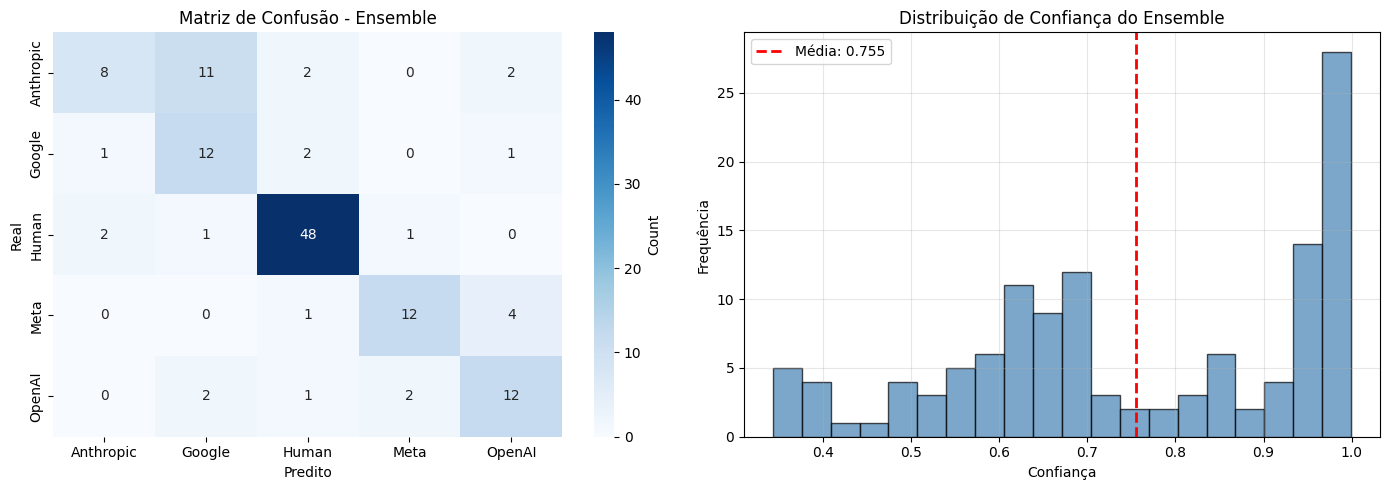


Confiança média do ensemble: 0.7552
Confiança mín/máx: 0.3428 / 0.9994

COMPARAÇÃO DE MODELOS INDIVIDUAIS:
       Modelo  Accuracy
     Ensemble     0.736
  MLP (Subm3)     0.680
   DistilBERT     0.680
DNN (Subm2-A)     0.648


In [63]:
# ============================================================
# FUNÇÃO: Votação Ponderada do Ensemble
# ============================================================

def get_ensemble_predictions(texts):
    """
    Combina predições dos modelos treinados no notebook usando média ponderada de probabilidades.
    Os pesos são proporcionais à performance de validação dos modelos disponíveis.
    """
    all_predictions = {}
    all_probs = {}
    model_weights = {}

    # Modelo 1: MLP
    x_vec_mlp = features_fit_mlp.transform(texts).astype(np.float32).toarray()
    x_vec_mlp_t = torch.tensor(x_vec_mlp, dtype=torch.float32).to(DEVICE)
    with torch.no_grad():
        probs_mlp = torch.softmax(mlp_model(x_vec_mlp_t), dim=1).cpu().numpy()
    all_predictions['mlp'] = np.argmax(probs_mlp, axis=1)
    all_probs['mlp'] = probs_mlp
    model_weights['mlp'] = float(mlp_val_acc)

    # Modelo 2: DNN Subm2-A
    x_vec_subm2a = features_fit_subm2a.transform(texts).astype(np.float32).toarray()
    x_vec_subm2a_t = torch.tensor(x_vec_subm2a, dtype=torch.float32).to(DEVICE)
    with torch.no_grad():
        probs_subm2a = torch.softmax(subm2a_model(x_vec_subm2a_t), dim=1).cpu().numpy()
    all_predictions['subm2a'] = np.argmax(probs_subm2a, axis=1)
    all_probs['subm2a'] = probs_subm2a
    model_weights['subm2a'] = float(subm2a_val_acc)

    # Modelo 3: DistilBERT
    if has_bert:
        bert_ds = BERTDataset(texts, np.zeros(len(texts), dtype=np.int64), bert_tokenizer, max_len=256)
        bert_loader = DataLoader(bert_ds, batch_size=8, shuffle=False, num_workers=0)
        bert_probs = []
        bert_preds = []

        with torch.no_grad():
            for batch in bert_loader:
                input_ids = batch['input_ids'].to(DEVICE)
                attention_mask = batch['attention_mask'].to(DEVICE)
                outputs = bert_model(input_ids=input_ids, attention_mask=attention_mask)
                probs = torch.softmax(outputs.logits, dim=1).cpu().numpy()
                bert_probs.append(probs)
                bert_preds.append(np.argmax(probs, axis=1))

        probs_bert = np.vstack(bert_probs)
        all_predictions['bert'] = np.concatenate(bert_preds)
        all_probs['bert'] = probs_bert
        model_weights['bert'] = float(bert_val_acc)

    n_samples = len(texts)
    weighted_probs = np.zeros((n_samples, len(classes)), dtype=np.float32)
    total_weight = 0.0

    for model_name, probs in all_probs.items():
        weight = model_weights[model_name]
        weighted_probs += probs * weight
        total_weight += weight

    weighted_probs /= total_weight
    ensemble_preds = np.argmax(weighted_probs, axis=1)
    max_prob = np.max(weighted_probs, axis=1)

    return ensemble_preds, max_prob, all_predictions, weighted_probs, model_weights

# ============================================================
# AVALIAÇÃO DO ENSEMBLE NO DATASET DE TESTE
# ============================================================

print('\n' + '=' * 70)
print('AVALIANDO ENSEMBLE NO DATASET DE TESTE (dataset-exemplos)')
print('=' * 70)

x_test_text = df_test['Text'].astype(str).to_numpy(dtype=object)
ensemble_preds_test, ensemble_conf_test, individual_preds_test, ensemble_probs_test, ensemble_weights = get_ensemble_predictions(x_test_text)

ensemble_acc = accuracy_score(y_test, ensemble_preds_test)
ensemble_labels_test = [idx2label[p] for p in ensemble_preds_test]

print(f'\n✓ Accuracy do Ensemble: {ensemble_acc:.4f} ({ensemble_acc*100:.2f}%)')
print('\nPesos usados no ensemble:')
for model_name, weight in ensemble_weights.items():
    print(f'  - {model_name}: {weight:.4f}')

print('\nClassification Report (Ensemble):')
print(classification_report(y_test_str, ensemble_labels_test, digits=4))

cm_ensemble = confusion_matrix(y_test, ensemble_preds_test)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.heatmap(
    cm_ensemble,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=classes,
    yticklabels=classes,
    ax=axes[0],
    cbar_kws={'label': 'Count'}
)
axes[0].set_title('Matriz de Confusão - Ensemble')
axes[0].set_xlabel('Predito')
axes[0].set_ylabel('Real')

axes[1].hist(ensemble_conf_test, bins=20, edgecolor='black', alpha=0.7, color='steelblue')
axes[1].axvline(ensemble_conf_test.mean(), color='red', linestyle='--', linewidth=2, label=f'Média: {ensemble_conf_test.mean():.3f}')
axes[1].set_xlabel('Confiança')
axes[1].set_ylabel('Frequência')
axes[1].set_title('Distribuição de Confiança do Ensemble')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

print(f'\nConfiança média do ensemble: {ensemble_conf_test.mean():.4f}')
print(f'Confiança mín/máx: {ensemble_conf_test.min():.4f} / {ensemble_conf_test.max():.4f}')

print('\n' + '=' * 70)
print('COMPARAÇÃO DE MODELOS INDIVIDUAIS:')
print('=' * 70)

comparison_rows = []
mlp_preds_test = individual_preds_test['mlp']
subm2a_preds_test = individual_preds_test['subm2a']
comparison_rows.append({'Modelo': 'MLP (Subm3)', 'Accuracy': accuracy_score(y_test, mlp_preds_test)})
comparison_rows.append({'Modelo': 'DNN (Subm2-A)', 'Accuracy': accuracy_score(y_test, subm2a_preds_test)})
if has_bert and 'bert' in individual_preds_test:
    comparison_rows.append({'Modelo': 'DistilBERT', 'Accuracy': accuracy_score(y_test, individual_preds_test['bert'])})
comparison_rows.append({'Modelo': 'Ensemble', 'Accuracy': ensemble_acc})

comparison_df = pd.DataFrame(comparison_rows).sort_values('Accuracy', ascending=False)
print(comparison_df.to_string(index=False))

## Análise de Desacordos, Artefactos e Persistência

> Analisamos onde os modelos concordam ou divergem e guardamos os modelos treinados e a configuração do ensemble.


ANÁLISE DE DESACORDOS - Casos discordantes entre modelos

Total de erros do ensemble: 33/125 (26.4%)

Exemplos de erros do ensemble:
   ID      Real  Ensemble  Ensemble_Confiança       MLP DNN_Subm2A DistilBERT  N_Modelos_Concordam
 D1-3    Google    OpenAI              0.6274    OpenAI     OpenAI     Google                    2
 D1-4      Meta    OpenAI              0.6073    OpenAI     OpenAI       Meta                    2
 D1-7    OpenAI    Google              0.4052 Anthropic     Google      Human                    1
 D1-8      Meta    OpenAI              0.5957    OpenAI     OpenAI       Meta                    2
D1-10     Human Anthropic              0.4910 Anthropic       Meta  Anthropic                    2
D1-16    OpenAI     Human              0.3964 Anthropic     OpenAI      Human                    1
D1-20 Anthropic    Google              0.7040 Anthropic     Google     Google                    2
D1-30 Anthropic    Google              0.6471    Google     Google      Hu

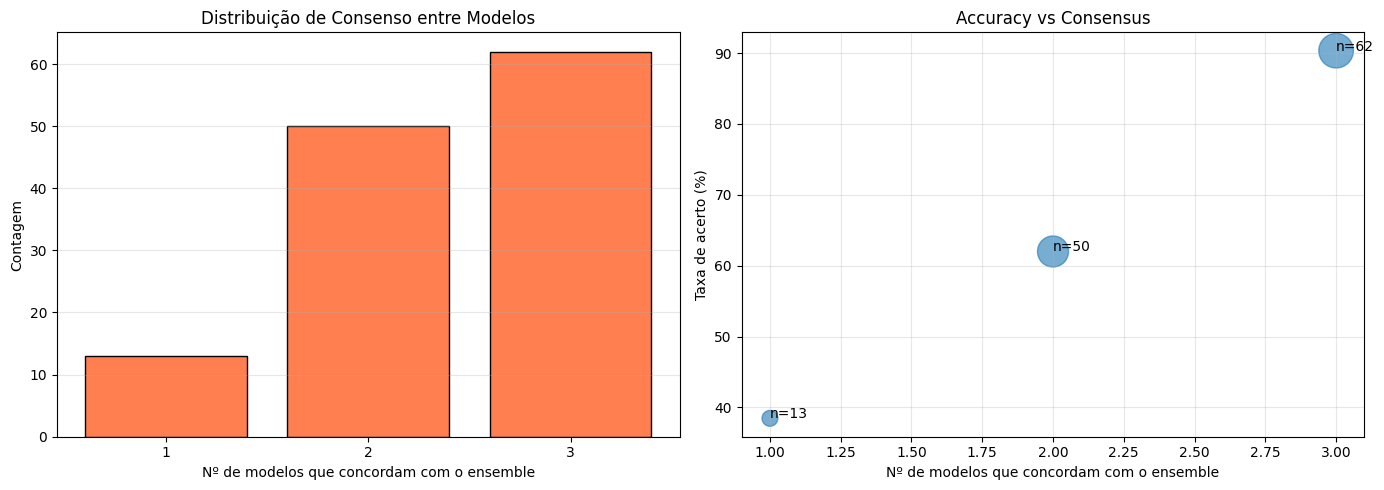


GUARDANDO RESUMO DO ENSEMBLE
✓ Configuração do ensemble atualizada em: /Users/nunoaraujo/MIA/AP/AP-25_26/saved/subm3_ensemble_config.joblib


In [64]:
# ============================================================
# ANÁLISE DE DESACORDOS ENTRE MODELOS
# ============================================================

print('\n' + '=' * 70)
print('ANÁLISE DE DESACORDOS - Casos discordantes entre modelos')
print('=' * 70)

comparison_detailed = pd.DataFrame({
    'ID': df_test['ID'].values if 'ID' in df_test.columns else range(len(df_test)),
    'Real': y_test_str,
    'Ensemble': ensemble_labels_test,
    'Ensemble_Confiança': ensemble_conf_test.round(4),
    'MLP': [idx2label[p] for p in individual_preds_test['mlp']],
    'DNN_Subm2A': [idx2label[p] for p in individual_preds_test['subm2a']],
})
if has_bert and 'bert' in individual_preds_test:
    comparison_detailed['DistilBERT'] = [idx2label[p] for p in individual_preds_test['bert']]

prediction_cols = [col for col in ['MLP', 'DNN_Subm2A', 'DistilBERT'] if col in comparison_detailed.columns]
comparison_detailed['N_Modelos_Concordam'] = sum(
    (comparison_detailed[col] == comparison_detailed['Ensemble']).astype(int) for col in prediction_cols
)

erros_ensemble = comparison_detailed['Real'] != comparison_detailed['Ensemble']
n_erros = int(erros_ensemble.sum())
print(f'\nTotal de erros do ensemble: {n_erros}/{len(df_test)} ({n_erros/len(df_test)*100:.1f}%)')
if n_erros > 0:
    print('\nExemplos de erros do ensemble:')
    print(comparison_detailed[erros_ensemble].head(10).to_string(index=False))

n_required = len(prediction_cols)
desacordos = comparison_detailed['N_Modelos_Concordam'] < n_required
n_desacordos = int(desacordos.sum())
print(f'\nTotal de desacordos: {n_desacordos}/{len(df_test)} ({n_desacordos/len(df_test)*100:.1f}%)')
if n_desacordos > 0:
    print('\nExemplos de desacordo:')
    cols_to_show = ['ID', 'Real', 'Ensemble', 'Ensemble_Confiança', 'N_Modelos_Concordam'] + prediction_cols
    print(comparison_detailed[desacordos][cols_to_show].head(10).to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
consensus_counts = comparison_detailed['N_Modelos_Concordam'].value_counts().sort_index()
axes[0].bar(consensus_counts.index.astype(str), consensus_counts.values, color='coral', edgecolor='black')
axes[0].set_xlabel('Nº de modelos que concordam com o ensemble')
axes[0].set_ylabel('Contagem')
axes[0].set_title('Distribuição de Consenso entre Modelos')
axes[0].grid(alpha=0.3, axis='y')

correct = comparison_detailed['Real'] == comparison_detailed['Ensemble']
scatter_x = []
scatter_y = []
scatter_s = []
scatter_labels = []
for n_agree in consensus_counts.index:
    mask = comparison_detailed['N_Modelos_Concordam'] == n_agree
    scatter_x.append(n_agree)
    scatter_y.append(correct[mask].mean() * 100)
    scatter_s.append(mask.sum() * 10)
    scatter_labels.append(f'n={mask.sum()}')
axes[1].scatter(scatter_x, scatter_y, s=scatter_s, alpha=0.6)
for x, y, label in zip(scatter_x, scatter_y, scatter_labels):
    axes[1].annotate(label, (x, y))
axes[1].set_xlabel('Nº de modelos que concordam com o ensemble')
axes[1].set_ylabel('Taxa de acerto (%)')
axes[1].set_title('Accuracy vs Consensus')
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

print('\n' + '=' * 70)
print('GUARDANDO RESUMO DO ENSEMBLE')
print('=' * 70)
ensemble_config = joblib.load(ENSEMBLE_PATH)
ensemble_config.update({
    'weights_used_on_test': ensemble_weights,
    'test_accuracy': float(ensemble_acc),
    'test_n_samples': int(len(df_test)),
    'ensemble_errors': n_erros,
    'ensemble_disagreements': n_desacordos,
})
joblib.dump(ensemble_config, ENSEMBLE_PATH)
print(f'✓ Configuração do ensemble atualizada em: {ENSEMBLE_PATH}')

## Gerar Submissão com Ensemble

> Aplicamos o ensemble treinado neste notebook ao `subm3.csv` e preparamos o ficheiro final.


GERANDO SUBMISSÃO COM ENSEMBLE PARA SUBM3

Preview das primeiras 10 predições:
       ID      Label  Confidence
0  D2-126      Human    0.937842
1  D2-127  Anthropic    0.452257
2  D2-128  Anthropic    0.546759
3  D2-129      Human    0.993277
4  D2-130     OpenAI    0.504840
5  D2-131       Meta    0.923928
6  D2-132  Anthropic    0.617215
7  D2-133  Anthropic    0.869924
8  D2-134     OpenAI    0.559711
9  D2-135     Google    0.889491

Distribuição de labels preditos pelo ensemble:
Label
Human        50
OpenAI       31
Meta         25
Anthropic    22
Google       22
Name: count, dtype: int64

Estatísticas da submissão:
  - Total de amostras: 150
  - Confiança média: 0.7887
  - Confiança mín/máx: 0.2928 / 0.9991

Casos com desacordo: 63/150

Exemplos de desacordo (primeiros 5):
    ID  Ensemble  Ensemble_Conf       MLP DNN_Subm2A DistilBERT  N_Concordam
D2-127 Anthropic         0.4523     Human  Anthropic  Anthropic            2
D2-128 Anthropic         0.5468 Anthropic  Anthropic  

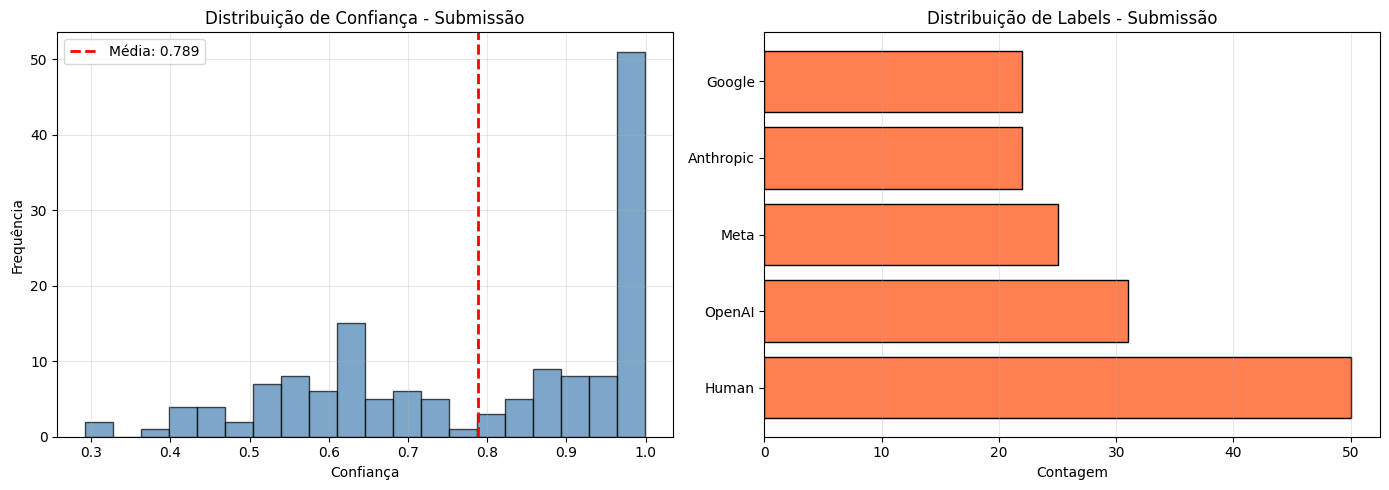


EXPORTAÇÃO DE FICHEIRO
✓ Submissão gerada em: /Users/nunoaraujo/MIA/AP/AP-25_26/Subm3/subm3-g3-MIA-B.csv


In [65]:
# ============================================================
# GERAR SUBMISSÃO COM ENSEMBLE
# ============================================================

print('\n' + '=' * 70)
print('GERANDO SUBMISSÃO COM ENSEMBLE PARA SUBM3')
print('=' * 70)

x_subm3_text = df_subm3['Text'].astype(str).to_numpy(dtype=object)
ensemble_preds_subm3, ensemble_conf_subm3, individual_preds_subm3, ensemble_probs_subm3, ensemble_weights_subm3 = get_ensemble_predictions(x_subm3_text)
ensemble_labels_subm3 = [idx2label[p] for p in ensemble_preds_subm3]

df_submission = pd.DataFrame({
    'ID': df_subm3['ID'],
    'Label': ensemble_labels_subm3,
    'Confidence': ensemble_conf_subm3,
})

print('\nPreview das primeiras 10 predições:')
print(df_submission.head(10))
print('\nDistribuição de labels preditos pelo ensemble:')
print(df_submission['Label'].value_counts())
print('\nEstatísticas da submissão:')
print(f'  - Total de amostras: {len(df_submission)}')
print(f'  - Confiança média: {ensemble_conf_subm3.mean():.4f}')
print(f'  - Confiança mín/máx: {ensemble_conf_subm3.min():.4f} / {ensemble_conf_subm3.max():.4f}')

analysis_df = pd.DataFrame({
    'ID': df_subm3['ID'],
    'Ensemble': ensemble_labels_subm3,
    'Ensemble_Conf': ensemble_conf_subm3.round(4),
    'MLP': [idx2label[p] for p in individual_preds_subm3['mlp']],
    'DNN_Subm2A': [idx2label[p] for p in individual_preds_subm3['subm2a']],
})
if has_bert and 'bert' in individual_preds_subm3:
    analysis_df['DistilBERT'] = [idx2label[p] for p in individual_preds_subm3['bert']]

pred_cols_subm3 = [col for col in ['MLP', 'DNN_Subm2A', 'DistilBERT'] if col in analysis_df.columns]
analysis_df['N_Concordam'] = sum((analysis_df[col] == analysis_df['Ensemble']).astype(int) for col in pred_cols_subm3)
n_desacordos_subm3 = int((analysis_df['N_Concordam'] < len(pred_cols_subm3)).sum())
print(f'\nCasos com desacordo: {n_desacordos_subm3}/{len(df_subm3)}')
if n_desacordos_subm3 > 0:
    print('\nExemplos de desacordo (primeiros 5):')
    print(analysis_df[analysis_df['N_Concordam'] < len(pred_cols_subm3)].head(5).to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].hist(ensemble_conf_subm3, bins=20, edgecolor='black', alpha=0.7, color='steelblue')
axes[0].axvline(ensemble_conf_subm3.mean(), color='red', linestyle='--', linewidth=2, label=f'Média: {ensemble_conf_subm3.mean():.3f}')
axes[0].set_xlabel('Confiança')
axes[0].set_ylabel('Frequência')
axes[0].set_title('Distribuição de Confiança - Submissão')
axes[0].legend()
axes[0].grid(alpha=0.3)

label_counts = df_submission['Label'].value_counts()
axes[1].barh(label_counts.index, label_counts.values, color='coral', edgecolor='black')
axes[1].set_xlabel('Contagem')
axes[1].set_title('Distribuição de Labels - Submissão')
axes[1].grid(alpha=0.3, axis='x')
plt.tight_layout()
plt.show()

print('\n' + '=' * 70)
print('EXPORTAÇÃO DE FICHEIRO')
print('=' * 70)
SUBM3_OUTPUT = SUBM3_DIR / 'subm3-g3-MIA-B.csv'

output_path = SUBM3_DIR / 'subm3-g3-MIA-B.csv'
df_submission[['ID', 'Label']].to_csv(output_path, sep=';', index=False, encoding='utf-8-sig')
print(f'✓ Submissão gerada em: {output_path}')